# 03 - Rule-based Behavior Engine (Vung cam / Lang vang / Nguoi la)

**Khong chay lai video** - dung thang file log da co san tu Notebook 02
(`annotated_output_detections.csv`, da co san `track_id`, `bbox`, `timestamp_sec`).

**3 loai canh bao:**
1. `unknown_face` - track_id lien tuc khong khop voi ai trong gallery qua N frame lien tiep
2. `zone_intrusion` - vi tri chan (bottom-center bbox) cua track_id nam trong 1 vung cam (ROI polygon)
3. `loitering` - track_id xuat hien lien tuc qua X giay (lang vang)

**Gioi han da biet (quan trong):** cot `matched_person` trong log hien tai dung chung gia tri `'unknown'`
cho ca 2 truong hop khac nhau: (a) khong thay mat nao trong crop nguoi (vd quay lung),
va (b) thay mat nhung khong khop gallery (nguoi la that su). Notebook nay tam chap nhan
gop chung 2 truong hop do (vi ca 2 deu la tin hieu "khong xac dinh duoc danh tinh", van
dang gia tri de canh bao). Neu can phan biet ro rang hon, se can sua Notebook 02 de ghi
them cot rieng `face_detected`.

In [1]:
# ===== CELL 1: Thiet lap duong dan & doc log tu Notebook 02 =====
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = r'D:\Code\Face recognition security system'
AI_DIR = os.path.join(BASE_DIR, 'ai')

CASCADE_OUT_DIR = os.path.join(AI_DIR, 'dataset', 'cascade_test_output')
VIDEO_PATH = os.path.join(AI_DIR, 'dataset', 'Hai recognition.mp4')
DETECTION_LOG_PATH = os.path.join(CASCADE_OUT_DIR, 'annotated_output_detections.csv')

assert os.path.exists(DETECTION_LOG_PATH), (
    f"Chua thay {DETECTION_LOG_PATH} - chay xong Cell 11 cua Notebook 02 truoc (can co video test)"
)
assert os.path.exists(VIDEO_PATH), f"Chua thay video tai {VIDEO_PATH}"

log_df = pd.read_csv(DETECTION_LOG_PATH)
log_df = log_df.sort_values(['frame', 'track_id']).reset_index(drop=True)

print(f"Da doc log: {len(log_df)} dong")
print(f"So track_id duy nhat: {log_df['track_id'].nunique()}")
print(f"Khoang thoi gian: {log_df['timestamp_sec'].min():.1f}s -> {log_df['timestamp_sec'].max():.1f}s")
log_df.head()


Da doc log: 422 dong
So track_id duy nhat: 1
Khoang thoi gian: 2.3s -> 16.4s


,frame,timestamp_sec,track_id,bbox_x1,bbox_y1,bbox_x2,bbox_y2,matched_person,match_score,person_conf
0,70,2.34,1,513,23,720,445,unknown,NaN,0.494
1,71,2.37,1,425,7,720,740,unknown,NaN,0.487
2,72,2.40,1,342,1,720,977,unknown,NaN,0.859
3,73,2.44,1,309,0,720,1131,unknown,NaN,0.846
4,74,2.47,1,291,0,720,1228,unknown,NaN,0.848


## Buoc 1 - Xem khung hinh dau + luoi toa do de chon vung cam (ROI)

Xem anh voi luoi (grid) de uoc luong toa do pixel cho vung cam - doi so voi noi dung video that cua ban
(vi du: khu vuc cua ra vao, ke tu lieu...).

Kich thuoc khung hinh: 720 x 1280


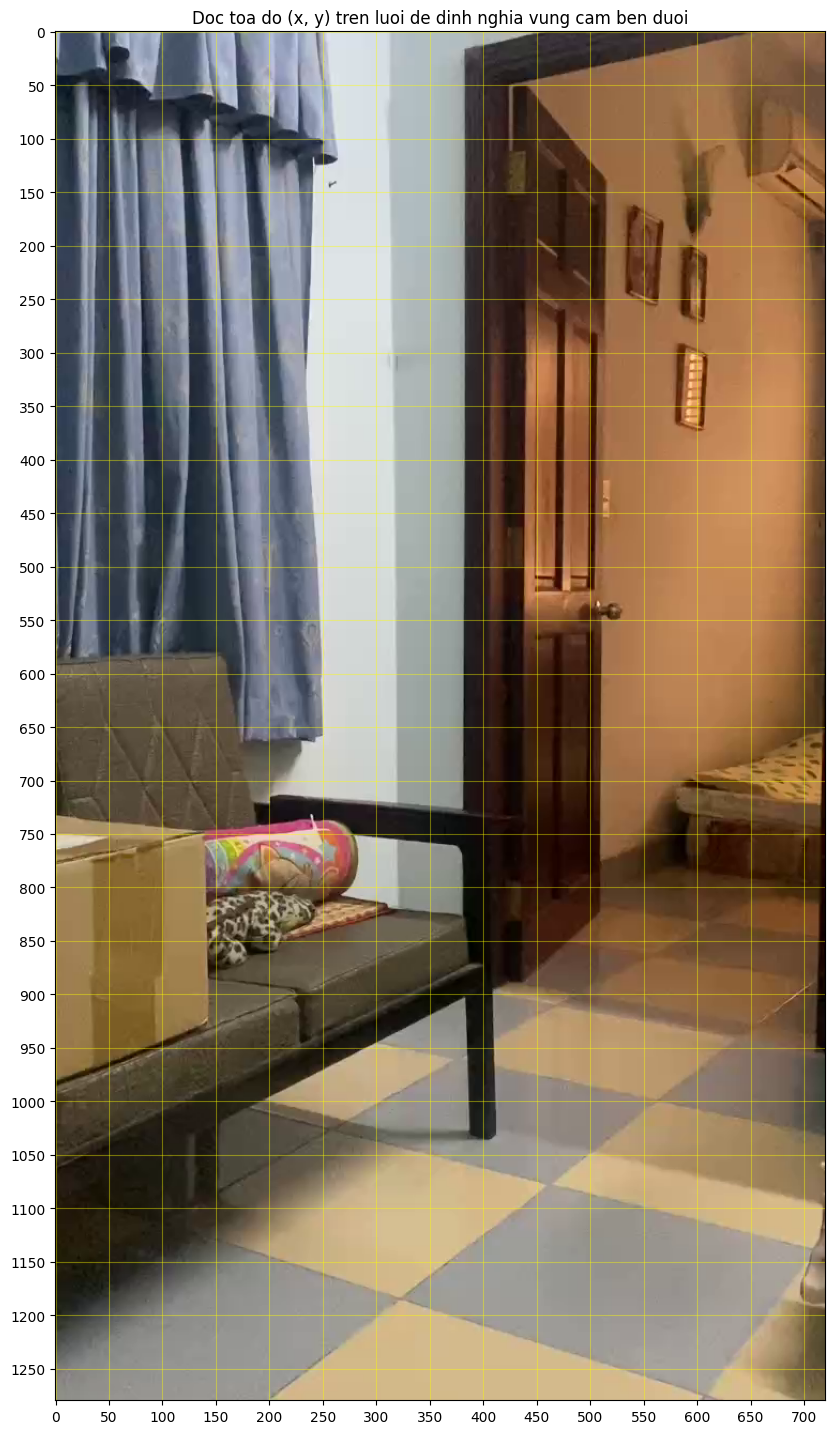

In [2]:
# ===== CELL 2: Xem khung hinh dau + luoi toa do =====
cap = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()

assert ret, "Khong doc duoc khung hinh dau cua video"

frame_h, frame_w = first_frame.shape[:2]
print(f"Kich thuoc khung hinh: {frame_w} x {frame_h}")

fig, ax = plt.subplots(figsize=(10, 10 * frame_h / frame_w))
ax.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
ax.set_xticks(range(0, frame_w, 50))
ax.set_yticks(range(0, frame_h, 50))
ax.grid(True, color='yellow', alpha=0.4)
plt.title("Doc toa do (x, y) tren luoi de dinh nghia vung cam ben duoi")
plt.show()


## Buoc 2 - Dinh nghia vung cam (co the nhieu vung)

Vi du ben duoi la 1/4 duoi-phai khung hinh (tinh theo ty le % de khong phu thuoc do phan giai video that).
**Sua toa do nay cho dung noi dung video cua ban**, dua vao luoi toa do o Cell 2.

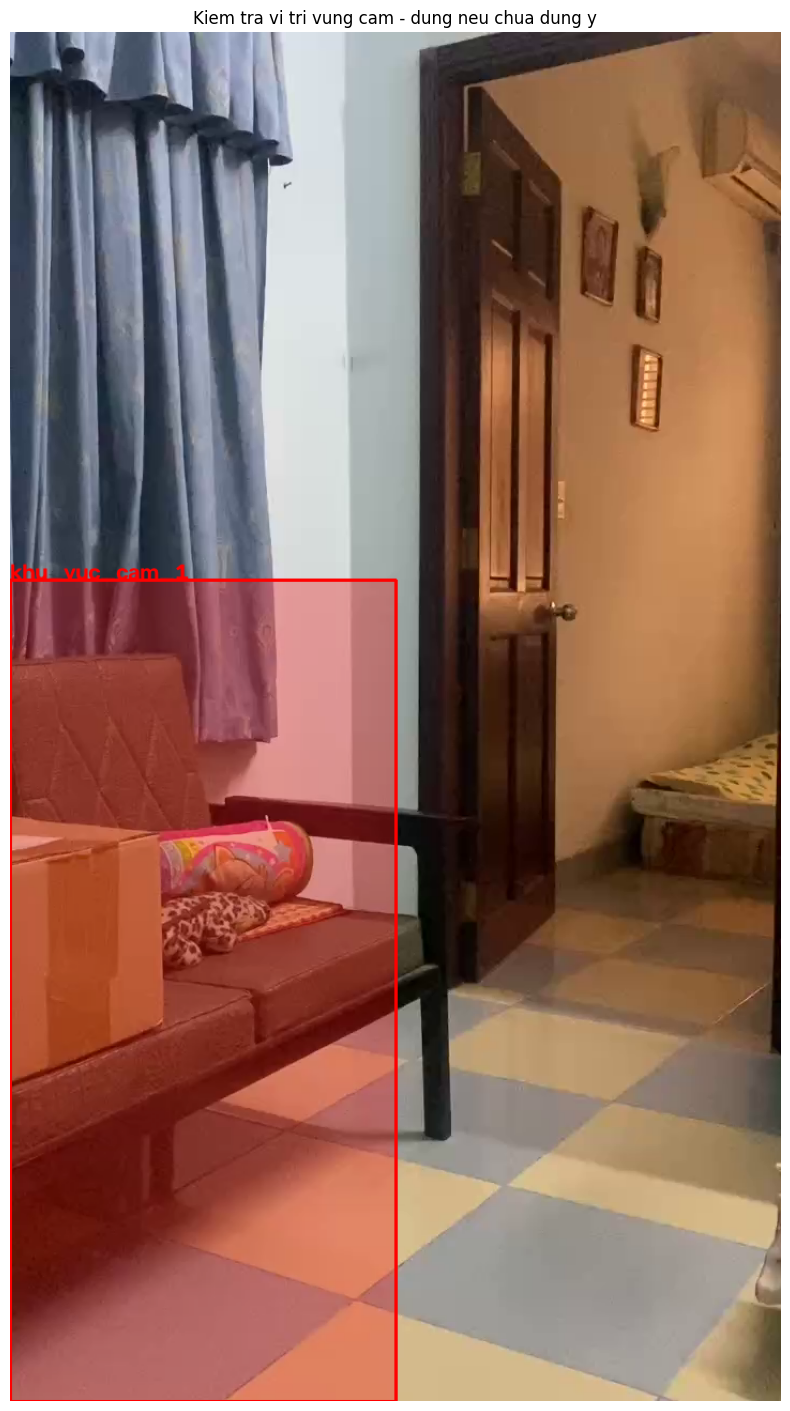

In [3]:
# ===== CELL 3: Dinh nghia vung cam - SUA LAI cho phu hop voi video that cua ban =====

# Vi du: vung cam la 1/4 duoi-trái khung hinh
example_zone_polygon = [
    (int(frame_w * 0.0), int(frame_h * 0.4)),
    (int(frame_w * 0.5), int(frame_h * 0.4)),
    (int(frame_w * 0.5), int(frame_h * 1.0)),
    (int(frame_w * 0.0), int(frame_h * 1.0)),
]

RESTRICTED_ZONES = [
    {'name': 'khu_vuc_cam_1', 'polygon': example_zone_polygon},
]

# Ve thu vung cam len khung hinh dau de kiem tra truc quan truoc khi chay full pipeline
preview = first_frame.copy()
for zone in RESTRICTED_ZONES:
    pts = np.array(zone['polygon'], dtype=np.int32)
    overlay = preview.copy()
    cv2.fillPoly(overlay, [pts], color=(0, 0, 255))
    preview = cv2.addWeighted(overlay, 0.3, preview, 0.7, 0)
    cv2.polylines(preview, [pts], isClosed=True, color=(0, 0, 255), thickness=2)
    cv2.putText(preview, zone['name'], pts[0], cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

plt.figure(figsize=(10, 10 * frame_h / frame_w))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title("Kiem tra vi tri vung cam - dung neu chua dung y")
plt.axis('off')
plt.show()


## Buoc 3 - BehaviorRuleEngine (thiet ke de dung lai duoc cho backend sau nay)

Class nay nhan tung "su kien" (`track_id, bbox, is_known, timestamp`) theo dung thu tu thoi gian -
mo phong dung cach backend se goi no SAU NAY (moi frame goi 1 lan, real-time), khong phai
xu ly hang loat 1 lan. Nho vay code nay co the copy gan nhu nguyen ven sang
`backend/app/services/pipeline_runner.py` khi tich hop that.

Co co che **cooldown** cho moi loai alert - tranh spam canh bao lien tuc moi frame khi
1 nguoi van con dung trong vung cam (chi bao lai sau moi `alert_cooldown_seconds` giay).

In [4]:
# ===== CELL 4: BehaviorRuleEngine =====

class BehaviorRuleEngine:
    def __init__(self, restricted_zones=None, loitering_seconds=30,
                 unknown_min_frames=5, alert_cooldown_seconds=10):
        self.restricted_zones = restricted_zones or []
        self.loitering_seconds = loitering_seconds
        self.unknown_min_frames = unknown_min_frames
        self.alert_cooldown_seconds = alert_cooldown_seconds

        self.track_state = {}  # track_id -> dict trang thai

    def _point_in_zone(self, point, polygon):
        contour = np.array(polygon, dtype=np.int32)
        result = cv2.pointPolygonTest(contour, point, False)
        return result >= 0

    def _should_fire(self, state, alert_key, timestamp):
        """Chi tra ve True neu chua tung bao, hoac da qua cooldown ke tu lan bao truoc."""
        last_time = state['last_alert_time'].get(alert_key)
        if last_time is None or (timestamp - last_time) >= self.alert_cooldown_seconds:
            state['last_alert_time'][alert_key] = timestamp
            return True
        return False

    def evaluate(self, track_id, bbox, is_known, timestamp):
        """Goi 1 lan cho MOI phat hien (track_id, bbox) tai 1 thoi diem, theo dung thu tu thoi gian.
        Tra ve list ten cac alert duoc kich hoat tai thoi diem nay (co the rong)."""
        x1, y1, x2, y2 = bbox
        foot_point = (int((x1 + x2) / 2), int(y2))  # vi tri chan - chuan cho giam sat khong gian

        state = self.track_state.setdefault(track_id, {
            'first_seen': timestamp,
            'last_seen': timestamp,
            'unknown_streak': 0,
            'last_alert_time': {},
        })
        state['last_seen'] = timestamp

        triggered = []

        # 1) Nguoi la (khong xac dinh duoc danh tinh lien tuc qua N frame)
        if not is_known:
            state['unknown_streak'] += 1
        else:
            state['unknown_streak'] = 0

        if state['unknown_streak'] >= self.unknown_min_frames:
            if self._should_fire(state, 'unknown_face', timestamp):
                triggered.append('unknown_face')

        # 2) Vung cam
        for zone in self.restricted_zones:
            if self._point_in_zone(foot_point, zone['polygon']):
                alert_key = f"zone_intrusion:{zone['name']}"
                if self._should_fire(state, alert_key, timestamp):
                    triggered.append(alert_key)

        # 3) Lang vang (xuat hien lien tuc qua nguong thoi gian)
        dwell_seconds = state['last_seen'] - state['first_seen']
        if dwell_seconds >= self.loitering_seconds:
            if self._should_fire(state, 'loitering', timestamp):
                triggered.append('loitering')

        return triggered

print("Da dinh nghia BehaviorRuleEngine")


Da dinh nghia BehaviorRuleEngine


## Buoc 4 - Chay engine tren toan bo log (mo phong goi lien tuc theo thoi gian)

In [6]:
# ===== CELL 5: Chay BehaviorRuleEngine tren log_df =====

engine = BehaviorRuleEngine(
    restricted_zones=RESTRICTED_ZONES,
    loitering_seconds=30,
    unknown_min_frames=5,
    alert_cooldown_seconds=10,
)

alert_rows = []

for _, row in log_df.iterrows():
    bbox = (row['bbox_x1'], row['bbox_y1'], row['bbox_x2'], row['bbox_y2'])
    is_known = row['matched_person'] != 'unknown'

    triggered = engine.evaluate(
        track_id=row['track_id'],
        bbox=bbox,
        is_known=is_known,
        timestamp=row['timestamp_sec'],
    )

    for alert_type in triggered:
        alert_rows.append([
            row['frame'], row['timestamp_sec'], row['track_id'],
            row['matched_person'], alert_type,
        ])

alerts_df = pd.DataFrame(alert_rows, columns=[
    'frame', 'timestamp_sec', 'track_id', 'matched_person', 'alert_type',
])

alerts_csv_path = os.path.join(AI_DIR, 'dataset', 'behavior_alerts.csv')
alerts_df.to_csv(alerts_csv_path, index=False)

print(f"Tong so alert kich hoat: {len(alerts_df)}")
if len(alerts_df):
    print(alerts_df['alert_type'].value_counts())
print(f"\nLuu tai: {alerts_csv_path}")
alerts_df.head(20)


Tong so alert kich hoat: 3
alert_type
unknown_face                    2
zone_intrusion:khu_vuc_cam_1    1
Name: count, dtype: int64

Luu tai: D:\Code\Face recognition security system\ai\dataset\behavior_alerts.csv


,frame,timestamp_sec,track_id,matched_person,alert_type
0,74,2.47,1,unknown,unknown_face
1,370,12.36,1,Tran_Tuan_Hai,zone_intrusion:khu_vuc_cam_1
2,379,12.66,1,unknown,unknown_face


In [7]:
# ===== CELL 6: Tom tat theo tung track_id (moi nguoi/doi tuong duoc theo doi) =====

summary_rows = []
for track_id, group in log_df.groupby('track_id'):
    dwell = group['timestamp_sec'].max() - group['timestamp_sec'].min()
    matched_names = group.loc[group['matched_person'] != 'unknown', 'matched_person'].unique()
    track_alerts = alerts_df[alerts_df['track_id'] == track_id]['alert_type'].unique().tolist()

    summary_rows.append([
        track_id,
        round(dwell, 1),
        ', '.join(matched_names) if len(matched_names) else 'khong xac dinh',
        ', '.join(track_alerts) if track_alerts else '-',
    ])

summary_df = pd.DataFrame(summary_rows, columns=[
    'track_id', 'thoi_gian_xuat_hien_s', 'danh_tinh_nhan_duoc', 'canh_bao_da_kich_hoat',
])
summary_df


,track_id,thoi_gian_xuat_hien_s,danh_tinh_nhan_duoc,canh_bao_da_kich_hoat
0,1,14.1,Tran_Tuan_Hai,"unknown_face, zone_intrusion:khu_vuc_cam_1"


## Tong ket Notebook 03

Ket qua:
- `ai/data/behavior_alerts.csv` - toan bo alert kich hoat (frame, timestamp, track_id, loai alert)
- Bang tom tat theo tung `track_id` o Cell 6 - thoi gian xuat hien, danh tinh, cac alert da kich hoat

**Nhung gia tri co the can tinh chinh sau khi xem ket qua that:**
- `loitering_seconds=30` - neu video test ngan hon 30s, se KHONG BAO GIO thay alert `loitering`
  (dieu nay binh thuong, khong phai loi - chi la video chua du dai de test rule nay)
- `unknown_min_frames=5` - neu FPS trich xuat thap, 5 frame co the tuong duong vai giay; dieu chinh
  theo FPS thuc te cua video
- Toa do `RESTRICTED_ZONES` - can khop voi noi dung video that, khong phai gia tri vi du mac dinh

**Buoc tiep theo (Notebook 04):** danh gia dinh luong toan bo he thong - mAP/FPS cho detection,
Accuracy/FAR/FRR cho recognition (bao gom ca phan test "nguoi la" con thieu tu Notebook 02),
va doi chieu voi WIDER FACE / MOT17 neu con thoi gian.